<a href="https://colab.research.google.com/github/rocio-mr/clustering-mcd/blob/main/Actividad_7_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use el dataset Iris y entrene los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

In [ ]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

#Cargar el dataset
iris = load_iris()

#Separar en X y y
X = iris.data
y = iris.target

In [ ]:
#Primero escalaremos los datos
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)


In [ ]:
#Asignamos el número de clusters con K  = 3
kmeans = KMeans(n_clusters=3, random_state=42)
#Entrenamos
kmeans.fit(X_escalado)

KMeans(n_clusters=3, random_state=42)

In [ ]:
centroides = kmeans.cluster_centers_
centroides

array([[ 0.57100359, -0.37176778,  0.69111943,  0.66315198],
       [-0.81623084,  1.31895771, -1.28683379, -1.2197118 ],
       [-1.32765367, -0.373138  , -1.13723572, -1.11486192]])

In [ ]:
labels_kmeans = kmeans.fit_predict(X_escalado)
labels_kmeans

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
#DBSCAN

#Configuramos y entrenamos el DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan.fit(X_escalado)

DBSCAN(eps=0.8)

In [ ]:
#Obtenemos las etiquetas
labels_dbscan = dbscan.fit_predict(X_escalado)
labels_dbscan

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [ ]:
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

n_noise = list(labels_dbscan).count(-1)

print("Número de clusters:", n_clusters_dbscan)
print("Número de puntos de ruido:", n_noise)

Número de clusters: 2
Número de puntos de ruido: 4


In [ ]:
#Spectral Clustering

spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
labels_spectral = spectral.fit_predict(X_escalado)

In [ ]:
labels_spectral

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0,
       0, 2, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [ ]:
#Métricas de validación externa (Adjusted Rand Index (ARI) y V-measure)

In [ ]:
from sklearn.metrics import adjusted_rand_score, v_measure_score
import pandas as pd
modelos = {
    "K-Means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "Spectral Clustering": labels_spectral
}

resultados_externos = []

for nombre, labels in modelos.items():

    ari = adjusted_rand_score(y, labels)
    v_measure = v_measure_score(y, labels)

    resultados_externos.append([
        nombre,
        ari,
        v_measure
    ])

resultados_externos = pd.DataFrame(
    resultados_externos,
    columns=[
        "Modelo",
        "Adjusted Rand Index (ARI)",
        "V-Measure"
    ]
)



resultados_externos

,Modelo,Adjusted Rand Index (ARI),V-Measure
0,K-Means,0.432805,0.589567
1,DBSCAN,0.551755,0.689979
2,Spectral Clustering,0.646487,0.683763


In [ ]:
#Métricas de validación interna

#Silhouette Score y Davies-Bouldin Index

from sklearn.metrics import silhouette_score, davies_bouldin_score

resultados_internos = []

for nombre, labels in modelos.items():

    # DBSCAN puede generar ruido con etiqueta -1
    if -1 in labels:

        mask = labels != -1

        X_eval = X_escalado[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X_escalado
        labels_eval = labels

    # Verificar que existan al menos 2 clusters
    if len(set(labels_eval)) >= 2:

        silhouette = silhouette_score(
            X_eval,
            labels_eval
        )

        davies_bouldin = davies_bouldin_score(
            X_eval,
            labels_eval
        )

    else:

        silhouette = np.nan
        davies_bouldin = np.nan

    resultados_internos.append([
        nombre,
        silhouette,
        davies_bouldin
    ])

resultados_internos = pd.DataFrame(
    resultados_internos,
    columns=[
        "Modelo",
        "Silhouette Score",
        "Davies-Bouldin Index"
    ]
)

resultados_internos

,Modelo,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.479881,0.789363
1,DBSCAN,0.597941,0.568802
2,Spectral Clustering,0.459301,0.822362


In [ ]:
#Elbow Method (Método del codo)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_escalado)

    inertias.append(kmeans.inertia_)

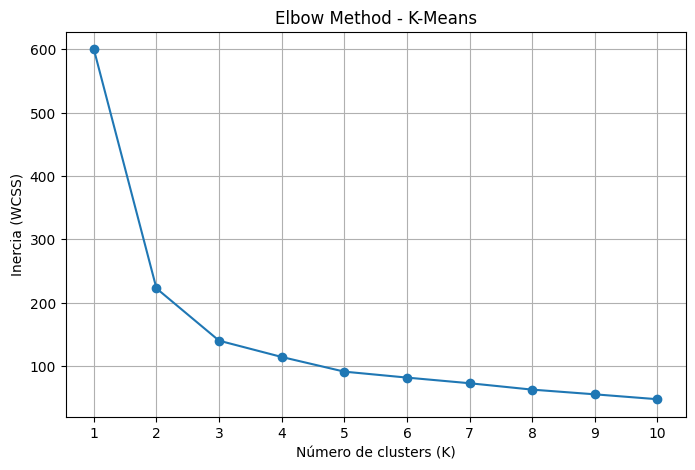

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertias,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Elbow Method - K-Means")

plt.xticks(K)

plt.grid(True)

plt.show()

Use el dataset sintético moons y entrene los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

In [ ]:
#Ahora trabajamos con el dataset moons

from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

In [ ]:
X

array([[ 0.83058575, -0.44773257],
       [ 0.70167816,  0.81691843],
       [ 1.02208004, -0.49257102],
       [-0.31676455,  0.95343844],
       [ 0.29322631,  1.05718523],
       [ 1.25490304, -0.48343549],
       [ 1.05385133, -0.44269047],
       [ 0.03137971,  1.05301203],
       [ 0.62054473,  0.71309598],
       [ 1.7876566 , -0.14295878],
       [ 0.99907493,  0.09180641],
       [-0.70723041,  0.57499903],
       [ 1.46479643, -0.47111862],
       [ 0.42712245,  0.83103216],
       [ 1.05341942, -0.50102941],
       [ 1.19597671, -0.49472393],
       [ 1.99422286,  0.42426007],
       [ 0.93175527,  0.39426183],
       [ 0.41104275, -0.33348189],
       [ 1.49073255, -0.38560138],
       [ 1.97517181,  0.35930615],
       [ 2.0470942 ,  0.41068552],
       [-0.00592133,  0.14862165],
       [ 0.82592072, -0.42998975],
       [ 0.54309448,  0.75144817],
       [ 1.8709548 ,  0.20141701],
       [ 1.9224317 ,  0.43263225],
       [-0.86765136,  0.45505598],
       [ 0.28216036,

In [ ]:
#Nuevamente se estandarizan los datos

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

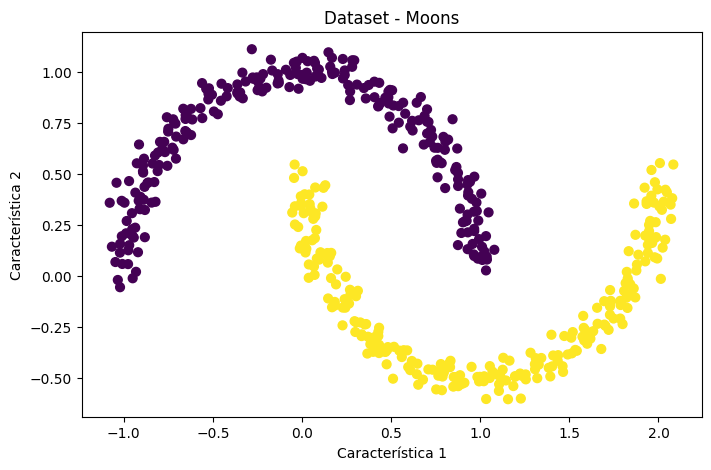

In [ ]:
#Visualizamos los datos reales
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=40
)

plt.title("Dataset - Moons")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
#Empezamos con KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_escalado)
labels_kmeans

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,

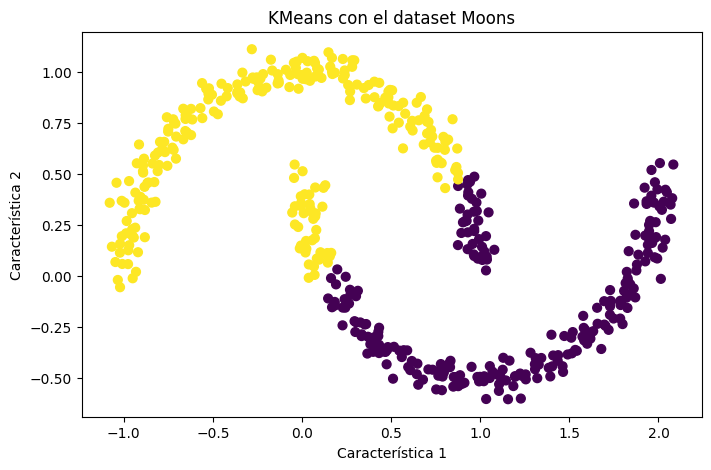

In [ ]:
#Visualizamos el modelo KMeans

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_kmeans,
    s=40
)

plt.title("KMeans con el dataset Moons")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
#Entrenamos DBScan

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_escalado)
labels_dbscan

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [ ]:
#Comprobamos cuantos clusters encontró
n_clusters_dbscan = len(
    set(labels_dbscan)
) - (1 if -1 in labels_dbscan else 0)

n_ruido = list(labels_dbscan).count(-1)

print("Número de clusters:", n_clusters_dbscan)
print("Puntos considerados ruido:", n_ruido)

Número de clusters: 2
Puntos considerados ruido: 0


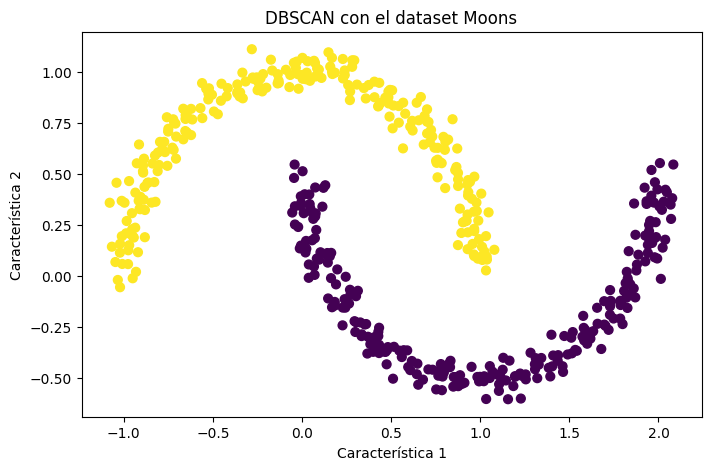

In [ ]:
#Visualizamos el modelo DBSCAN

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_dbscan,
    s=40
)

plt.title("DBSCAN con el dataset Moons")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
#Por último tenemos Spectral Clustering

spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    random_state=42
)

labels_spectral = spectral.fit_predict(X_escalado)
labels_spectral

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

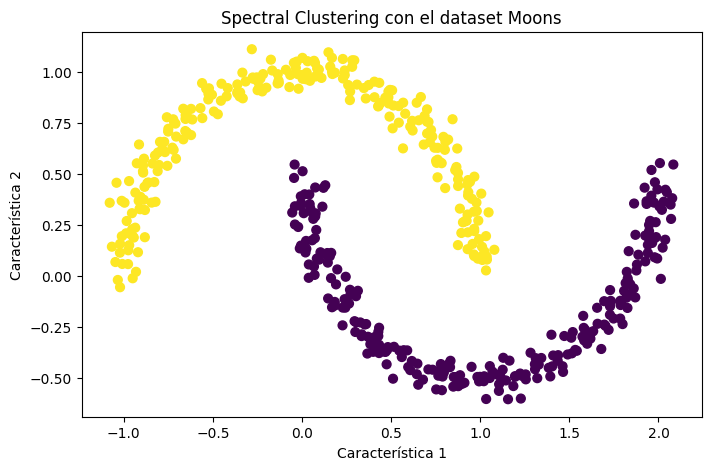

In [ ]:
#Visualizamos el modelo entrenado con Spectral Clustering

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_spectral,
    s=40
)

plt.title("Spectral Clustering con el dataset Moons")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

In [ ]:
#Métricas de validación externa

modelos = {
    "K-Means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "Spectral Clustering": labels_spectral
}

resultados_externos = []

for nombre, labels in modelos.items():

    ari = adjusted_rand_score(y, labels)

    v_measure = v_measure_score(y, labels)

    resultados_externos.append([
        nombre,
        ari,
        v_measure
    ])

resultados_externos = pd.DataFrame(
    resultados_externos,
    columns=[
        "Modelo",
        "Adjusted Rand Index (ARI)",
        "V-Measure"
    ]
)

resultados_externos


,Modelo,Adjusted Rand Index (ARI),V-Measure
0,K-Means,0.445112,0.35163
1,DBSCAN,1.000000,1.00000
2,Spectral Clustering,1.000000,1.00000


In [ ]:
#Ahora pasamos a las métricas de validación interna
import numpy as np

resultados_internos = []

for nombre, labels in modelos.items():

    # El -1 representa ruido en DBSCAN
    if -1 in labels:

        mask = labels != -1

        X_eval = X_escalado[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X_escalado
        labels_eval = labels

    # Verificar que existan al menos 2 clusters
    if len(np.unique(labels_eval)) >= 2:

        silhouette = silhouette_score(
            X_eval,
            labels_eval
        )

        davies_bouldin = davies_bouldin_score(
            X_eval,
            labels_eval
        )

    else:

        silhouette = np.nan
        davies_bouldin = np.nan

    resultados_internos.append([
        nombre,
        silhouette,
        davies_bouldin
    ])

resultados_internos = pd.DataFrame(
    resultados_internos,
    columns=[
        "Modelo",
        "Silhouette Score",
        "Davies-Bouldin Index"
    ]
)

resultados_internos

,Modelo,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.496150,0.810714
1,DBSCAN,0.389338,1.017883
2,Spectral Clustering,0.389338,1.017883


In [ ]:
inertias = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_escalado)

    inertias.append(kmeans.inertia_)

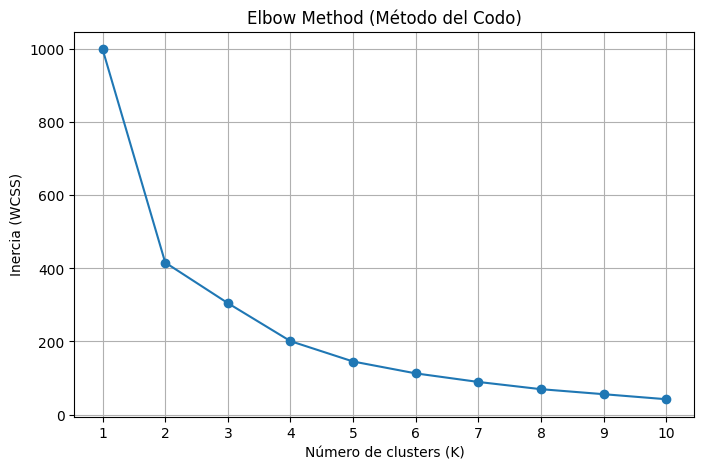

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertias,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Elbow Method (Método del Codo)")

plt.xticks(K)
plt.grid(True)

plt.show()

Use el dataset sintético circle y entren los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

In [ ]:
from sklearn.datasets import make_circles

In [ ]:
X, y = make_circles(
    n_samples=400,
    noise=0.05,
    factor=0.5,
    random_state=42
)

In [ ]:
#Estandarizamos los datos

scaler = StandardScaler()
X_circles_escalado = scaler.fit_transform(X)

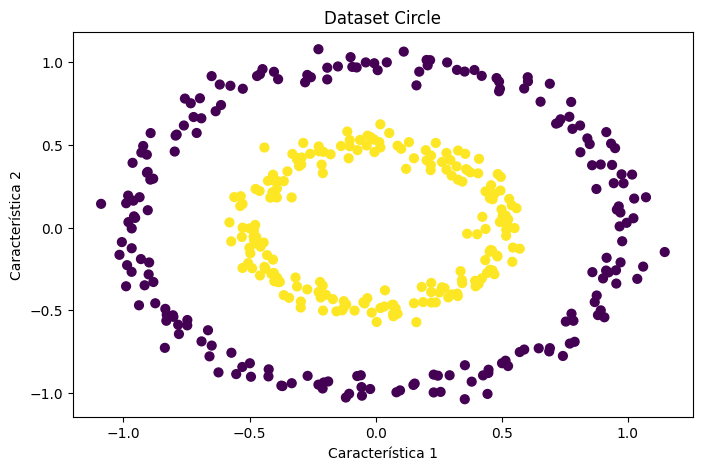

In [ ]:
#Visualizamos los datos

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=40
)

plt.title("Dataset Circle")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
#Entrenamos K-means

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

In [ ]:
labels_kmeans_circles = kmeans.fit_predict(X_circles_escalado)
labels_kmeans_circles

array([1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,

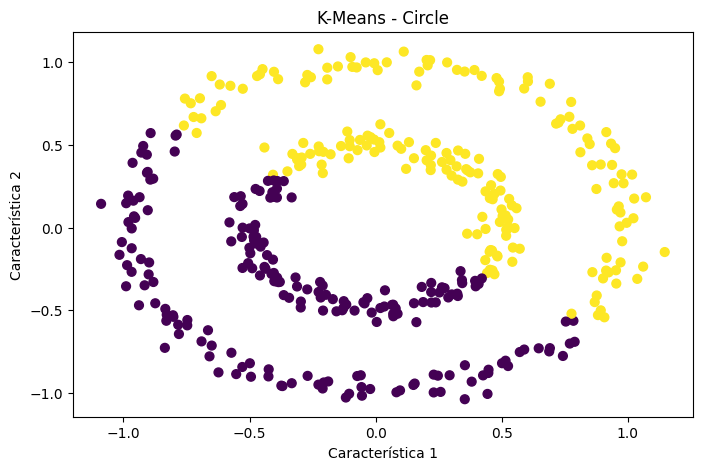

In [ ]:
#Visualizar mi modelo KMeans para el dataset de circles

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_kmeans_circles,
    s=40
)

plt.title("K-Means - Circle")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
#Ahora el segundo modelo DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan_circles = dbscan.fit_predict(X_circles_escalado)
labels_dbscan_circles

array([0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,

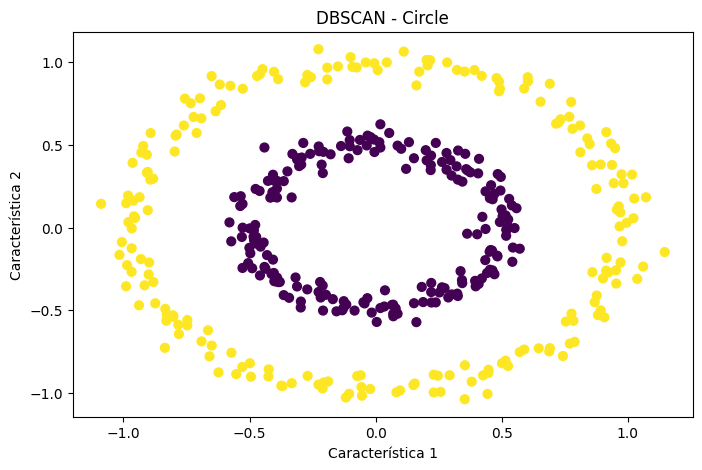

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_dbscan_circles,
    s=40
)

plt.title("DBSCAN - Circle")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
n_clusters_dbscan = len(
    set(labels_dbscan)
) - (1 if -1 in labels_dbscan else 0)

n_ruido = list(labels_dbscan).count(-1)

print("Número de clusters:", n_clusters_dbscan)
print("Puntos considerados ruido:", n_ruido)

Número de clusters: 2
Puntos considerados ruido: 0


In [ ]:
#Entrenando el Spectral Clustering

spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    random_state=42
)

labels_spectral = spectral.fit_predict(X_circles_escalado)
labels_spectral

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,

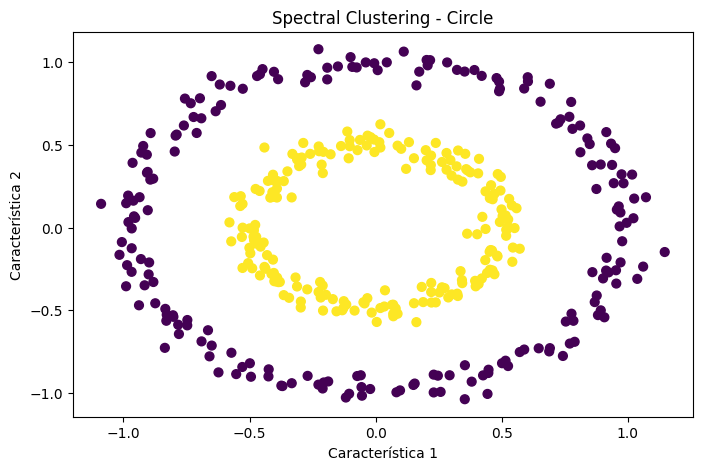

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_spectral,
    s=40
)

plt.title("Spectral Clustering - Circle")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.show()

In [ ]:
modelos = {
    "K-Means": labels_kmeans_circles,
    "DBSCAN": labels_dbscan_circles,
    "Spectral Clustering": labels_spectral
}

resultados_externos = []

for nombre, labels in modelos.items():

    ari = adjusted_rand_score(
        y,
        labels
    )

    v_measure = v_measure_score(
        y,
        labels
    )

    resultados_externos.append([
        nombre,
        ari,
        v_measure
    ])

resultados_externos = pd.DataFrame(
    resultados_externos,
    columns=[
        "Modelo",
        "Adjusted Rand Index (ARI)",
        "V-Measure"
    ]
)

resultados_externos

,Modelo,Adjusted Rand Index (ARI),V-Measure
0,K-Means,-0.002411,0.000072
1,DBSCAN,1.000000,1.000000
2,Spectral Clustering,1.000000,1.000000


In [ ]:
#Métricas de validación interna

resultados_internos = []

for nombre, labels in modelos.items():

    # En DBSCAN, -1 representa ruido
    if -1 in labels:

        mask = labels != -1

        X_eval = X_circles_escalado[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X_circles_escalado
        labels_eval = labels

    # Verificar que existan al menos 2 clusters
    if len(np.unique(labels_eval)) >= 2:

        silhouette = silhouette_score(
            X_eval,
            labels_eval
        )

        davies_bouldin = davies_bouldin_score(
            X_eval,
            labels_eval
        )

    else:

        silhouette = np.nan
        davies_bouldin = np.nan

    resultados_internos.append([
        nombre,
        silhouette,
        davies_bouldin
    ])

resultados_internos = pd.DataFrame(
    resultados_internos,
    columns=[
        "Modelo",
        "Silhouette Score",
        "Davies-Bouldin Index"
    ]
)

resultados_internos

,Modelo,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.354496,1.175980
1,DBSCAN,0.110755,331.956363
2,Spectral Clustering,0.110755,331.956363


In [ ]:
inertias = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_circles_escalado)

    inertias.append(kmeans.inertia_)

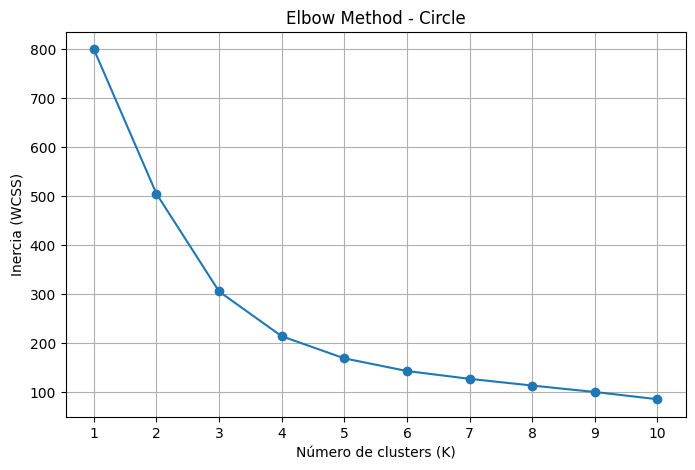

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertias,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Elbow Method - Circle")

plt.xticks(K)
plt.grid(True)

plt.show()